In [84]:
import copy
import os
import numpy as np
import matplotlib.pyplot as plt
from pydmd import DMD
from pydmd.bopdmd import BOPDMD
from pydmd import DMDc
from scipy.signal import StateSpace, lsim, hilbert
from scipy.io import loadmat,savemat
import pysindy as ps
import scipy
import pickle
import control as ct
from sklearn.metrics import mean_squared_error
import seaborn as sns
import pandas as pd


In [85]:
def bopdmd_train_test(svd_rank,num_trials,training_set,training_voltage,test_voltage,train_time,test_time,Btilde,return_training_fit, 
                     conjugate_bool, stable_bool, noise_level, evaluate,C,D):
    optdmd = BOPDMD(svd_rank = svd_rank, compute_A = True) #make our opt and bop objects with the correct
                                                            #number of trials and svd rank
        
        
    if conjugate_bool == True and stable_bool == True:
        bopdmd = BOPDMD(svd_rank = svd_rank, num_trials = num_trials, compute_A = True, eig_constraints = {'stable', 'conjugate_pairs'})
    elif conjugate_bool == True and stable_bool == False:
        bopdmd = BOPDMD(svd_rank = svd_rank, num_trials = num_trials, compute_A = True, eig_constraints = {'conjugate_pairs'})
    elif stable_bool == True and conjugate_bool == False:
        bopdmd = BOPDMD(svd_rank = svd_rank, num_trials = num_trials, compute_A = True, eig_constraints = {'stable'})
    else:
        bopdmd = BOPDMD(svd_rank = svd_rank, num_trials = num_trials, compute_A = True)
    
#     rmse = mean_squared_error(training_set[:, 1], np.zeros(training_set[:, 1].shape), squared=False)
    training_set_func = training_set + np.random.normal(0,  (np.sqrt(np.mean(training_set**2))/ 100.0) * noise_level, training_set.shape)
    bopdmd.fit(training_set_func,train_time) #fit out data
    
    Atilde = bopdmd.A #get A matrix from bop
    
    
    
    #now we are going to see how well bop does on our test voltages. These will simulate a vacuum shot and
    #be a series of 3 state square waves that are fed into each of the four circuits
    if evaluate == True:
        tout,yout,xout = lsim((Atilde,Btilde,C,D),test_voltage,test_time)
    
        return Atilde,bopdmd,xout
    else:
        return Atilde,bopdmd
    
    if return_training_fit == True:
        tout_train,yout_train,xout_train = lsim((Atilde,Btilde,C,D),train_voltage,time)
        return xout_train
    

In [86]:
def make_graph(data,title,legend,impulse,time,*args): #data should be a list of what one wants plotted,title is a string,
                                  #legend is an array of strings,impulse is a boolean if one is plotting the ringdown of a shot
    '''
    Function for making graphs of circuit data in a particular configuration and order
    data: list of arrays to be plotted on the graph
    title: string to be used as plot title
    legend: array of strings indicating each legend entry. 
    impulse: bool. Changes the x-axis scale if the data being plotted is the tail end of the shot
    time: array. Time vector used when plotting
    single_element: string either 'L1','C','L2' that will plot just a row of the desired element. else leave blank do 
    this when you have time

    '''


    fig, ax = plt.subplots(nrows=3, ncols=4, sharex=True, sharey = 'row', figsize=(20, 15))
    fig.tight_layout()
    fig.text(0.5, -0.04, 'Time (ms)', ha='center', fontsize = 35)
    fig.text(-0.04, 0.175, 'Flux Coil Current (A)', va='center', rotation='vertical', fontsize = 28)
    fig.text(-0.04, 0.5, 'Cap. Voltage (V)', va='center', rotation='vertical', fontsize = 28)
    fig.text(-0.04, 0.825, 'Series Coil Current (A)', va='center', rotation='vertical', fontsize = 28)
    fig.text(.5,1.04,title,ha = 'center',fontsize =35 )
    
    if impulse == False:
        plt.xlim([0,4])


    L1 = [0,3,6,9]
    C = [1,4,7,10]
    L2 = [2,5,8,11]
    
    colors = ['r','k','--b']
    alphas = [1,.65,1]
    for i in range(len(L1)):
        count = 0
        for j in data:
            plt.subplot(3,4,i+1)
            plt.plot(1000*time,np.real(j[:,L1[i]]),colors[count],alpha = alphas[count])
            count = count + 1
        plt.grid()


    for i in range(len(C)):
        count = 0
        for j in data:
            plt.subplot(3,4,i+5)
            plt.plot(1000*time,np.real(j[:,C[i]]),colors[count],alpha = alphas[count])
            count = count + 1
        plt.grid()

    for i in range(len(L2)):
        count = 0
        for j in data:
            plt.subplot(3,4,i+9)
            plt.plot(1000*time,np.real(j[:,L2[i]]),colors[count],alpha = alphas[count])
            count = count + 1
        plt.grid()



    fig.legend(legend, fontsize = 25)
    


In [87]:
def make_row_graph(data, title, legend, impulse, time, *argv, plasma_line=False, ret=False):
    '''
    Function for making graphs of circuit data in a particular configuration and order
    data: list of arrays to be plotted on the graph
    title: string to be used as plot title
    legend: array of strings indicating each legend entry. 
    impulse: bool. Changes the x-axis scale if the data being plotted is the tail end of the shot
    time: array. Time vector used when plotting
    single_element: string either 'L1', 'C', 'L2' that will plot just a row of the desired element. else leave blank do 
    this when you have time
    '''
    
    # Create figure and axes
    fig, ax = plt.subplots(nrows=1, ncols=4, sharex=True, sharey='row', figsize=(15, 5), constrained_layout=True)
    fig.tight_layout()
    fig.text(0.5, 0.05, 'Time (ms)', ha='center', fontsize=20)
    fig.text(0.5, 1.04, title, ha='center', fontsize=35)

    # Set properties for each subplot
    for i in range(4):
        ax[i].set_facecolor('w')  # Set background color to white
        ax[i].spines['top'].set_color('black')
        ax[i].spines['right'].set_color('black')
        ax[i].spines['bottom'].set_color('black')
        ax[i].spines['left'].set_color('black')
        ax[i].xaxis.set_tick_params(color='black')
        ax[i].yaxis.set_tick_params(color='black')
        ax[i].grid(color='black', zorder=0, alpha = .5)  # Set grid lines to black and behind the data

    # Set limits if impulse is False
    if not impulse:
        plt.xlim([0, 4])

    # Data arrays
    L1 = [0, 3, 6, 9]
    C = [1, 4, 7, 10]
    L2 = [2, 5, 8, 11]
    alphas = [1, .65, 1]
    colors = ['r', 'k', '--b']

    # Function to set symmetric y-limits
    def set_symmetric_ylim(axis, data):
        min_val = min(np.min(np.real(d)) for d in data)
        max_val = max(np.max(np.real(d)) for d in data)
        limit = max(abs(min_val), abs(max_val))
        axis.set_ylim(-limit, limit)

    # Plot based on argv input
    if argv[0] == 'L1':
        for i in range(len(L1)):
            count = 0
            for j in data:
                ax[i].plot(1000 * time, np.real(j[:, L1[i]]), colors[count], alpha=alphas[count], zorder=1)
                ax[i].tick_params(labelsize=20)
                count += 1
                if plasma_line:
                    ax[i].axvline(x=1, color='b', linewidth=3, label='_nolegend_')
        set_symmetric_ylim(ax[i], [j[:, L1[i]] for j in data])
        fig.text(0.02, 0.55, 'Series Coil Current (A)', va='center', ha='center', rotation='vertical', fontsize=20)

    if argv[0] == 'C':
        for i in range(len(C)):
            count = 0
            for j in data:
                ax[i].plot(1000 * time, np.real(j[:, C[i]]), colors[count], alpha=alphas[count], zorder=1)
                ax[i].tick_params(labelsize=20)
                count += 1
                if plasma_line:
                    ax[i].axvline(x=1, color='b', linewidth=3, label='_nolegend_')
        set_symmetric_ylim(ax[i], [j[:, C[i]] for j in data])
        fig.text(0.02, 0.55, 'Cap. Voltage (V)', va='center', ha='center', rotation='vertical', fontsize=20)

    if argv[0] == 'L2':
        for i in range(len(L2)):
            count = 0
            for j in data:
                ax[i].plot(1000 * time, np.real(j[:, L2[i]]), colors[count], alpha=alphas[count], zorder=1)
                ax[i].tick_params(labelsize=20)
                count += 1
                if plasma_line:
                    ax[i].axvline(x=1, color='b', linewidth=3, label='_nolegend_')
        set_symmetric_ylim(ax[i], [j[:, L2[i]] for j in data])
        fig.text(0.02, 0.55, 'Flux Coil Current (A)', va='center', ha='center', rotation='vertical', fontsize=20)

    # Add legend
    fig.legend(legend, fontsize=15, loc='upper right')

    # Return figure if needed
    if ret:
        return fig, ax

    # return fig  # Always return the figure object

# Example of calling the function
# fig = make_row_graph(data, title, legend, impulse, time, *argv, plasma_line=False, ret=True)


In [88]:
filename = 'data/continuous_vacuum_ss_model'
with open(filename,'rb') as file:
    sysc = pickle.load(file)
    print(f'object successfully saved to {filename}')
A = sysc.A #A matrix from vacuum model
B = sysc.B #B matrix from vacuum model
C = sysc.C #C matrix from vacuum model
D = sysc.D #D matrix from vacuum model

print(np.shape(D))

opt_A = loadmat('data/opt_A_matrix').get('afull')
bop_A_vacuum = loadmat('data/bop_A_matrix_vacuum').get('atilde_bop_no_conj')
bop_A_vacuum_sim = loadmat('data/BOP_A_matrix_sim_data').get('matrix')
bop_on_plasma = loadmat('data/bop_dmd_on_plasma_shot_220816009').get('xout_bop_avg')


object successfully saved to data/continuous_vacuum_ss_model
(4, 4)


In [89]:
np.shape(bop_A_vacuum_sim)

(12, 12)

In [90]:
opt_A_sim = loadmat('data/opt_A_sim_matrix').get('afull')
bop_A_plasma = loadmat('data/bop_dmd_plasma_shot_220816009')
A_plasma = loadmat('data/analytic_plasma_model_updated_params_9-26-24').get('A_plasma')
bop_plasma_A_matrix = loadmat('data/bop_dmd_A_matrix_220816009').get('atilde_bop_no_conj')
# print(bop_plasma_A_matrix)

B_13 = np.vstack((B,np.ones((1,4))));

C_13 = np.hstack((C,np.ones((4,1))))

A_analytic = loadmat('data/analytic_model_updated_params_9-25-24').get('A') #New analytic model 9/25. Use this for better results
B_analytic = loadmat('data/analytic_B_updated_params_9-26-24').get('B')
LQR_BOP_outputs = loadmat('data/plotting_data/LQG_model_data/LQR_Outputs_for_bop_model').get('kf_outputs_tilde')
desired_bop_waveform = loadmat('data/plotting_data/LQG_model_data/desired_waveform_for_BOP_model').get('desired_signals_arr_tilde')
sysc.A = A_analytic
sysc.B = B_analytic

In [91]:
desired_bop_waveform.shape

(40001, 5)

In [92]:
print(np.linalg.eigvals(A_plasma))

[-6817.1771318 +114445.45628569j -6817.1771318 -114445.45628569j
 -5352.07689318+115776.32829097j -5352.07689318-115776.32829097j
 -5391.09980013+112931.04151052j -5391.09980013-112931.04151052j
 -4880.26154294+112823.37739387j -4880.26154294-112823.37739387j
 -2681.27633926     +0.j         -1423.75686972     +0.j
 -2005.51659351     +0.j         -1950.61292985     +0.j
 -1651.69656928     +0.j        ]


In [93]:
print(np.shape(LQR_BOP_outputs))
print(np.shape(A_analytic))

(40001, 5)
(12, 12)


## The next few cells will be devoted to making plots from a simulation of the LQG feedback loop

In [94]:
lqr_outputs = loadmat('data/plotting_data/LQG_model_data/LQR_outputs').get('LQR_outputs')
L2_current_flux_1_lqg = loadmat('data/plotting_data/LQG_model_data/L2_current_flux_1').get('L2_current_flux_1')
desired_L2_current_flux_1_lqg = loadmat('data/plotting_data/LQG_model_data/desired_L2_current_flux_1').get('desired_L2_flux_1')
                                                                                                         
                                                                                                           

<Figure size 432x288 with 0 Axes>

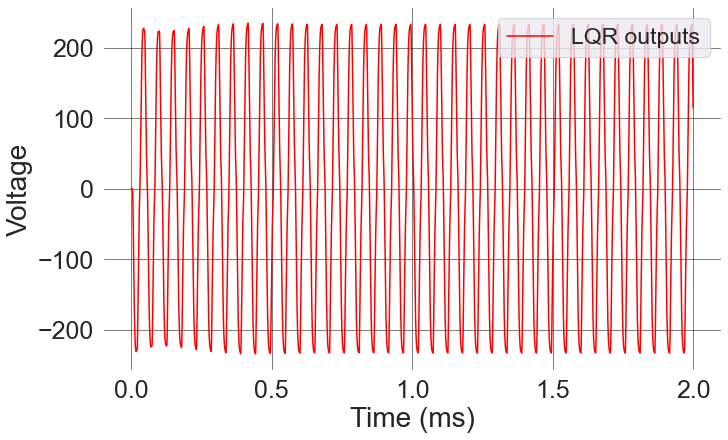

In [95]:
plt.figure()
lqg_time = np.linspace(0,.002,len(lqr_outputs))
lqg_time_ms = [ j*1000 for j in lqg_time]
# Plot the time series with a readable color scheme and markers
fig, ax = plt.subplots(figsize=(10, 6), facecolor='white', constrained_layout = True)
plt.rcParams['axes.axisbelow'] = True
# Set the background color of the axes to white
ax.set_facecolor('white')

# Plot the time series with a readable color scheme and markers
ax.plot(lqg_time_ms, lqr_outputs[:, 1], label='LQR outputs', color='red', linewidth=1.5)

# Add grid
ax.grid(color='black', linewidth=0.5, zorder = 0)

# Add legend, title, and labels with larger font size
ax.legend(fontsize=23, loc='upper right')
ax.set_title('', fontsize='xx-large', ha='center')  # Centered title
ax.set_xlabel('Time (ms)', fontsize=28, ha='center')  # Centered x-label
ax.set_ylabel('Voltage', fontsize=28, ha='center')  # Centered y-label
ax.tick_params(labelsize=25)

# Set x-axis limits if needed (uncomment and adjust as necessary)
# ax.set_xlim(0.002, 0.0021)

# Save the plot
plt.savefig('LQR_outputs.png', bbox_inches='tight')
plt.show()

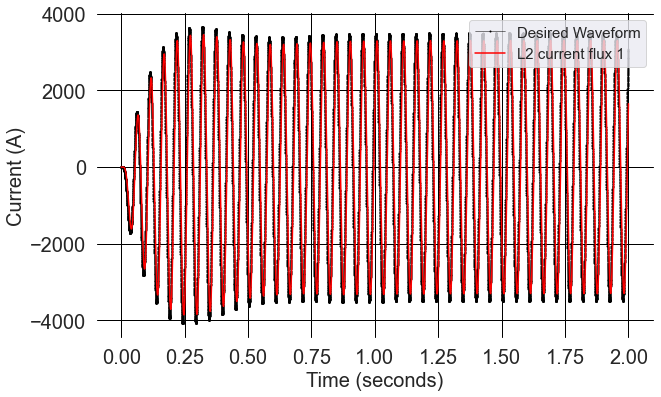

In [96]:
fig, ax = plt.subplots(figsize=(10, 6), facecolor='white')


# Plot the desired waveform
ax.plot(lqg_time_ms, desired_L2_current_flux_1_lqg, label='Desired Waveform', 
        color='black', marker='o', markersize=1, linewidth=0.5)

# Plot the L2 current flux
ax.plot(lqg_time_ms, L2_current_flux_1_lqg, label='L2 current flux 1', 
        color='red', linewidth=1.5)

# Add legend, title, and labels with specified font sizes
ax.legend(fontsize=15, loc='upper right')
ax.set_title('', fontsize='xx-large')
ax.set_xlabel('Time (seconds)', fontsize=20)
ax.set_ylabel('Current (A)', fontsize=20)
ax.tick_params(labelsize=20)
ax.set_facecolor('white')
# Set grid properties
ax.grid(color='black', zorder = 0)  # Set grid color to black

# Set x-axis limits if needed (adjust as necessary)
# ax.set_xlim([0.002, 0.0021])  # Uncomment and set limits if needed
ax.set_axisbelow(True)
# Save the plot
plt.savefig('Desired_vs_measured_L2_current_LQG.png', bbox_inches="tight")
plt.show()

c:\Users\ducks\anaconda3\lib\site-packages\matplotlib\cbook\__init__.py:1333: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


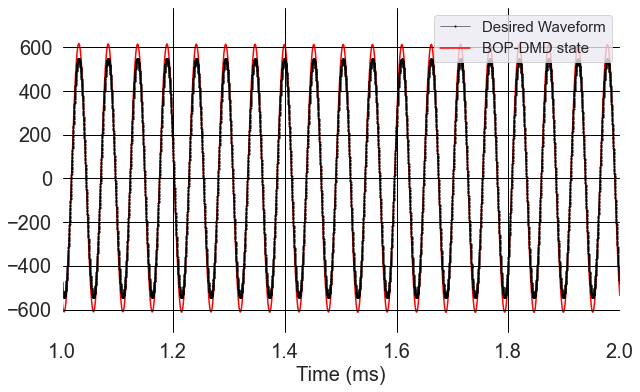

In [97]:


# Time axis
bop_lqg_time = np.linspace(0, 0.004, len(desired_bop_waveform))
bop_lqg_time = [t * 1000 for t in bop_lqg_time]

# Create a figure
fig, ax = plt.subplots(figsize=(10, 6), facecolor='white')

# Set the background color of the axes
ax.set_facecolor('white')

# Calculate max values for z-ordering
max_desired = desired_bop_waveform[:, 2].min()
max_lqr = LQR_BOP_outputs[:, 2].min()

# Plot the desired waveform
ax.plot(bop_lqg_time, desired_bop_waveform[:, 2], label='Desired Waveform', 
        color='black', marker='o', markersize=1, linewidth=0.5, zorder=max_desired)

# Plot the BOP-DMD state
ax.plot(bop_lqg_time, LQR_BOP_outputs[:, 2], label='BOP-DMD state', 
        color='red', linewidth=1.5, zorder=max_lqr)

# Add legend, title, and labels with specified font sizes
ax.legend(fontsize=15, loc='upper right')
ax.set_title('', fontsize='xx-large')
ax.set_xlabel('Time (ms)', fontsize=20)
ax.set_ylabel('', fontsize=20)
ax.tick_params(labelsize=20)

# Set grid properties
ax.grid(color='black', zorder = 0)  # Set grid color to black

# Set x-axis limits
ax.set_xlim([1, 2])  # Adjust the limits as needed
ax.set_axisbelow(True)
# Save the plot
plt.savefig('Desired_vs_measured_BOP_LQG.png', bbox_inches="tight")
plt.show()

In [98]:
def load_shot(directory,flux,plasma): #Pass in a directory as a string, and this function will cycle through the whole directory 
                             
    '''
    This function takes a file path and looks for .mat files containing the data from the HIT-SIU circuits. The function will
    cycle through the directory and pick out these files, and return lists of the circuit data configured in a specific order.
    
    parameters:
    directory: string. file path to desired .mat files to be loaded in.
    flux: bool. Determine if shot being loaded needs to look for flux circuit or voltage circuit variable names
    plasma: bool. Determine if toroidal plasma current ('i_tor') should be included in the time series
    '''   
        
    data_list = []
    for i in os.listdir(directory):
        if 'mat' in i:
            data_list.append(loadmat(f"{directory}/{i}"))

    # data_list.append(loadmat('data/vacuum_shots_220705_220707/220707001'))
    input_list = []
    state_list = []

    experiment_time = data_list[0].get('time')    
    experiment_time = experiment_time.reshape(len(experiment_time)) #reshape the time vector to a 0d array


#     data = loadmat('data/shot_220816005_data.mat')
#     vals = data['shot_220816005']
#     vals = vals[:,:]

#     voltage1 = vals[:,1]
#     voltage2 = vals[:,2]
#     voltage3 = vals[:,3]
#     voltage4 = vals[:,4]

    trajectory_list = []
    inputs_list = []
    state_deriv_list = []
    
    if flux == True:

        state_order = ['i_L1_1','v_cap_1','i_fcoil_1','i_L1_2','v_cap_2','i_fcoil_2','i_L1_3','v_cap_3','i_fcoil_3','i_L1_4','v_cap_4','i_fcoil_4']
        state_deriv_order = ['v_L1_1','i_cap_1','v_fcoil_1','v_L1_2','i_cap_2','v_fcoil_2','v_L1_3','i_cap_3','v_fcoil_3','v_L1_4','i_cap_4','v_fcoil_4']
    
    else:
        state_order = ['i_L1_1','v_cap_1','i_vcoil_1','i_L1_2','v_cap_2','i_vcoil_2','i_L1_3','v_cap_3','i_vcoil_3','i_L1_4','v_cap_4','i_vcoil_4']
        state_deriv_order = ['v_L1_1','i_cap_1','v_vcoil_1','v_L1_2','i_cap_2','v_vcoil_2','v_L1_3','i_cap_3','v_vcoil_3','v_L1_4','i_cap_4','v_vcoil_4']
    inputs_order = ['v_spa_1','v_spa_2','v_spa_3','v_spa_4']
    
    
    if plasma == True:
        state_order.append('i_tor')
        
        
    state_dict = dict.fromkeys(state_order)
    state_deriv_dict = dict.fromkeys(state_deriv_order)
    inputs_dict = dict.fromkeys(inputs_order)

    for d in data_list:

        for k,v in d.items():
            if k in state_dict:
                state_dict[k] = v
            if k in state_deriv_dict:
                state_deriv_dict[k] = v
            if k in inputs_dict:
                inputs_dict[k] = v


        trajectory_list.append(np.asarray(list(state_dict.values())).T)
        inputs_list.append(np.asarray(list((inputs_dict.values()))).T)
        state_deriv_list.append((np.asarray(list(state_deriv_dict.values())).T))




    for i in range(len(trajectory_list)):
        trajectory_list[i] = trajectory_list[i][0,:,:]
        inputs_list[i] = inputs_list[i][0,:,:]
        state_deriv_list[i] = state_deriv_list[i][0,:,:]

    return trajectory_list,inputs_list,state_deriv_list, experiment_time



In [99]:
directory = "data/vacuum_shots_220816/good_shots" #pull in vacuum shots
trajectory_list,inputs_list,state_deriv_list,experiment_time = load_shot(directory, flux = True, plasma = False) #Flux circuits in vacuum

flux_trajectory_list,flux_inputs_list,flux_state_deriv_list,experiment_time = load_shot('data/plasma_shots/flux_data/220816009',flux = True,plasma = True)

#pull in plasma shots
new_plasma_shot_list,new_plasma_shot_inputs_list,new_plasma_shot_state_deriv_list,new_plasma_shot_time = load_shot('data/plasma_shots/flux_data/220816008',flux=True,plasma=True) 

print(np.shape(new_plasma_shot_list[0]))

print(np.shape(flux_trajectory_list[0]))
print(np.shape(trajectory_list))

(2256, 13)
(2256, 13)
(3, 2256, 12)


In [100]:
np.linalg.eigvals(sysc.A)

array([-6814.64837996+114422.86185901j, -6814.64837996-114422.86185901j,
       -5352.02605022+115755.63643288j, -5352.02605022-115755.63643288j,
       -5391.66331814+112912.03454901j, -5391.66331814-112912.03454901j,
       -4883.77152563+112790.64005856j, -4883.77152563-112790.64005856j,
       -2673.23459651     +0.j        , -1634.70593131     +0.j        ,
       -2001.13901634     +0.j        , -1930.99463406     +0.j        ])

In [101]:
train = flux_trajectory_list[0][2256-484::,:].T
print(np.shape(train))



[t,y,xout_opt] = lsim((opt_A,B,C,D),inputs_list[2][251::,:],experiment_time[251::])
[t,y,xout_bop_plasma] = lsim((bop_plasma_A_matrix,B_13,C_13,D),flux_inputs_list[0][251::,:],experiment_time[251::])

[t,y,xout_bop_plasma_new_shot] = lsim((bop_plasma_A_matrix,B_13,C_13,D),new_plasma_shot_inputs_list[0][251::,:],experiment_time[251::])



(13, 484)


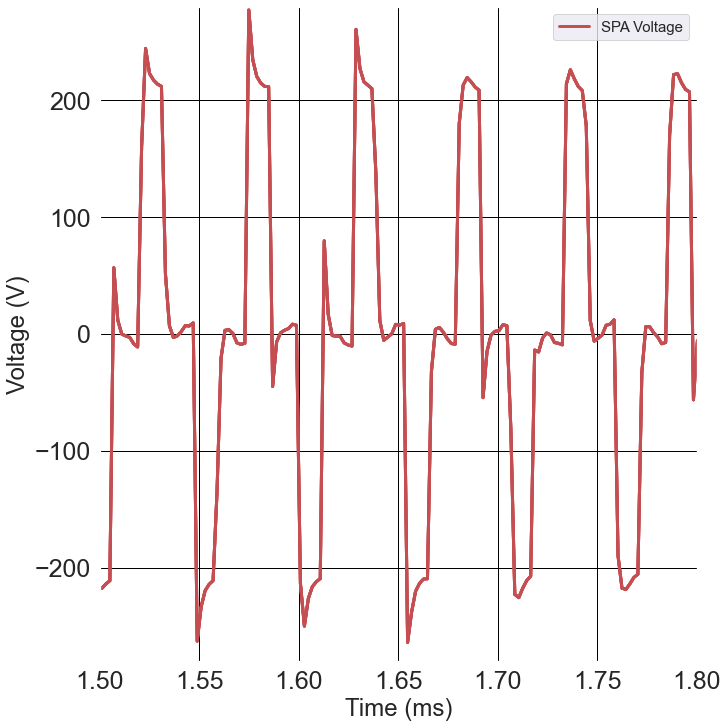

In [102]:
experiment_time_ms = [t * 1000 for t in experiment_time]

# Create figure and axes with white background
fig, ax = plt.subplots(figsize=(10, 10), facecolor='white', constrained_layout=True)

# Set axes background to white
ax.set_facecolor('white')

# Use a contrasting color for the grid
ax.grid(color='black', zorder = 0)  # Change to light gray for visibility

# Plot the data
ax.plot(experiment_time_ms[251:], flux_inputs_list[0][251:, :], 'r', linewidth = 3)
ax.set_xlabel('Time (ms)', fontsize=24)
ax.set_ylabel('Voltage (V)', fontsize=24)
ax.legend(['SPA Voltage'], fontsize=15)
ax.set_xlim([1.5, 1.8])  # Adjusted xlim for milliseconds
ax.tick_params(labelsize=25)
ax.set_ylim([-280,280])

# Save the plot
plt.savefig('SPA_voltage_of_an_experimental_shot.png', bbox_inches="tight")
plt.show()

## Plots of the flux circuits during a vacuum shot

(12, 484)


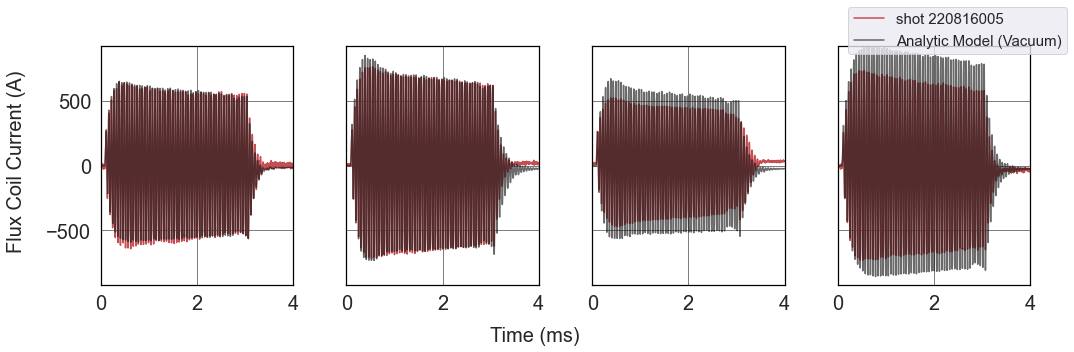

In [103]:
[t,y,xout_sim] = lsim(sysc, inputs_list[2][251::],experiment_time[251::])
row = 'L2'
make_row_graph([trajectory_list[2][251::,:],xout_sim],"",
           ['shot 220816005','Analytic Model (Vacuum)'],False, experiment_time[251::],row)
    
xout_train = trajectory_list[2][1772::,:]
tout_train = experiment_time[1772::].reshape(len(experiment_time[1772::]))



print(np.shape(xout_train.T))

plt.rcParams['savefig.facecolor']='white'
plt.savefig(f'analytic vs experimental data {row}',bbox_inches="tight")

(12, 484)


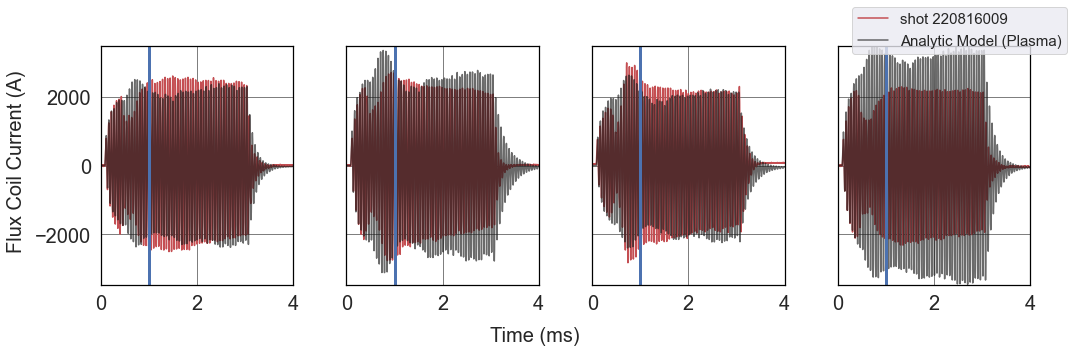

In [104]:
[t,y,xout_sim] = lsim(sysc, flux_inputs_list[0][251::],experiment_time[251::])
row = 'L2'
make_row_graph([flux_trajectory_list[0][251::,:],xout_sim],"",
           ['shot 220816009','Analytic Model (Plasma)'],False, experiment_time[251::],row, plasma_line = True)
    
xout_train = trajectory_list[2][1772::,:]
tout_train = experiment_time[1772::].reshape(len(experiment_time[1772::]))



print(np.shape(xout_train.T))

plt.savefig(f'analytic vs plasma data {row}',bbox_inches="tight")

In [105]:
print(np.shape(xout_sim[1000:1100,:]))
print(np.shape(trajectory_list[2][1251:1351,:]))


(100, 12)
(100, 12)


In [106]:
def make_row_graph_2(data,title,legend,impulse,time, *argv,plasma_line = False, ret = False): #data should be a list of what one wants plotted,title is a string,
                                  #legend is an array of strings,impulse is a boolean if one is plotting the ringdown of a shot
    '''
    Function for making graphs of circuit data in a particular configuration and order
    data: list of arrays to be plotted on the graph
    title: string to be used as plot title
    legend: array of strings indicating each legend entry. 
    impulse: bool. Changes the x-axis scale if the data being plotted is the tail end of the shot
    time: array. Time vector used when plotting
    single_element: string either 'L1','C','L2' that will plot just a row of the desired element. else leave blank do 
    this when you have time

    '''
    


    # Create figure and axes



    # Create figure and axes
    fig, ax = plt.subplots(nrows=1, ncols=4, sharex=True, sharey='row', figsize=(15, 5), constrained_layout = True)
    fig.tight_layout()
    fig.text(0.5, 0.05, 'Time (ms)', ha='center', fontsize=20)
    fig.text(0.5, 1.04, title, ha='center', fontsize=35)

    # Set properties for each subplot
    for i in range(4):
        ax[i].set_facecolor('w')  # Set background color to white
        ax[i].spines['top'].set_color('black')
        ax[i].spines['right'].set_color('black')
        ax[i].spines['bottom'].set_color('black')
        ax[i].spines['left'].set_color('black')
        ax[i].xaxis.set_tick_params(color='black')
        ax[i].yaxis.set_tick_params(color='black')
        ax[i].grid(color='black')  # Set grid lines to black

    # Set limits if impulse is False
    if impulse == False:
        plt.xlim([0, 4])

    # Data arrays
    L1 = [0, 3, 6, 9]
    C = [1, 4, 7, 10]
    L2 = [2, 5, 8, 11]
    alphas = [1, .65, 1]
    colors = ['r', 'k', '--b']

    # Function to set symmetric y-limits
    def set_symmetric_ylim(axis, data):
        min_val = min(np.min(np.real(d)) for d in data)
        max_val = max(np.max(np.real(d)) for d in data)
        limit = max(abs(min_val), abs(max_val))
        axis.set_ylim(-limit, limit)

    # Plot based on argv input
    if argv[0] == 'L1':
        for i in range(len(L1)):
            count = 0
            for j in data:
                ax[i].plot(1000 * time, np.real(j[:, L1[i]]), colors[count], alpha=alphas[count])
                ax[i].tick_params(labelsize=20)
                count += 1
                if plasma_line:
                    ax[i].axvline(x=1, color='b', linewidth=3, label='_nolegend_')
                ax[i].grid()
        set_symmetric_ylim(ax[i], [j[:, L1[i]] for j in data])
        fig.text(0.02, 0.5, 'Series Coil Current (A)', va='center', ha='center', rotation='vertical', fontsize=20)

    if argv[0] == 'C':
        for i in range(len(C)):
            count = 0
            for j in data:
                ax[i].plot(1000 * time, np.real(j[:, C[i]]), colors[count], alpha=alphas[count])
                ax[i].tick_params(labelsize=20)
                count += 1
                if plasma_line:
                    ax[i].axvline(x=1, color='b', linewidth=3, label='_nolegend_')
                ax[i].grid()
        set_symmetric_ylim(ax[i], [j[:, C[i]] for j in data])
        fig.text(0.02, 0.5, 'Cap. Voltage (V)', va='center', ha='center', rotation='vertical', fontsize=20)

    if argv[0] == 'L2':
        for i in range(len(L2)):
            count = 0
            for j in data:
                
                if count ==0:
                    ax[i].plot(1000 * time, np.real(j[:, L2[i]]), colors[count], alpha=alphas[count],linewidth = 5)
                else:
                    ax[i].plot(1000 * time, np.real(j[:, L2[i]]), colors[count], alpha=.8, linewidth = 2)   
                ax[i].tick_params(labelsize=20)
                count += 1
                print(i)
                if plasma_line:
                    ax[i].axvline(x=1, color='b', linewidth=3, label='_nolegend_')
                ax[i].grid()
        set_symmetric_ylim(ax[i], [j[:, L2[i]] for j in data])
        fig.text(0.02, 0.5, 'Flux Coil Current (A)', va='center', ha='center', rotation='vertical', fontsize=20)

    # Add legend
    fig.legend(legend, fontsize=15, loc='upper right')

    # Return figure if needed
    if ret:
        return fig,ax


0
0
1
1
2
2
3
3


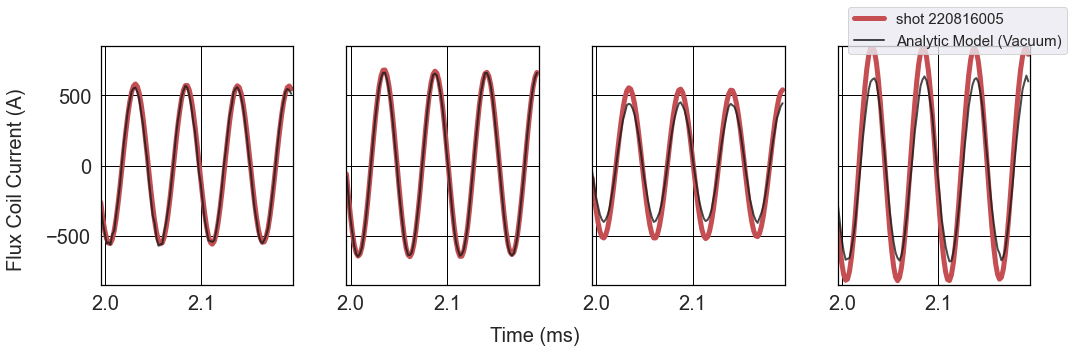

In [107]:
[t,y,xout_sim] = lsim(sysc, inputs_list[2][251::],experiment_time[251::])
row = 'L2'
fig = make_row_graph_2([xout_sim[1000:1100,:],trajectory_list[2][1251:1351,:] ],"",
           ['shot 220816005','Analytic Model (Vacuum)'],False, experiment_time[1251:1351],row, ret=True)
    
xout_train = trajectory_list[2][1772::,:]
tout_train = experiment_time[1772::].reshape(len(experiment_time[1772::]))
plt.xlim([experiment_time[1251]*1000,experiment_time[1351]*1000])



plt.savefig(f'analytic vs experimental data zoomed in {row}',bbox_inches="tight")

In [108]:
print(np.linalg.eigvals(sysc.A))

[-6814.64837996+114422.86185901j -6814.64837996-114422.86185901j
 -5352.02605022+115755.63643288j -5352.02605022-115755.63643288j
 -5391.66331814+112912.03454901j -5391.66331814-112912.03454901j
 -4883.77152563+112790.64005856j -4883.77152563-112790.64005856j
 -2673.23459651     +0.j         -1634.70593131     +0.j
 -2001.13901634     +0.j         -1930.99463406     +0.j        ]


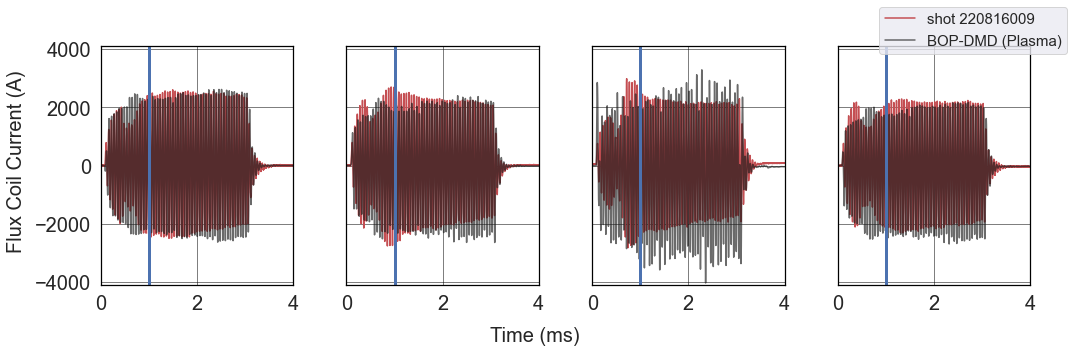

(12, 484)


<Figure size 432x288 with 0 Axes>

In [109]:
row = 'L2'
fig ,ax= make_row_graph([flux_trajectory_list[0][251::,:],bop_on_plasma],"",
           ['shot 220816009','BOP-DMD (Plasma)'],False, experiment_time[251::],row, plasma_line=True, ret = True)
    
xout_train = trajectory_list[2][1772::,:]
tout_train = experiment_time[1772::].reshape(len(experiment_time[1772::]))


for k in range(4):
    ax[k].set_ylim([-4100,4100])
plt.show()
print(np.shape(xout_train.T))

plt.savefig(f'BOP-DMD on plasma data {row}',bbox_inches="tight")

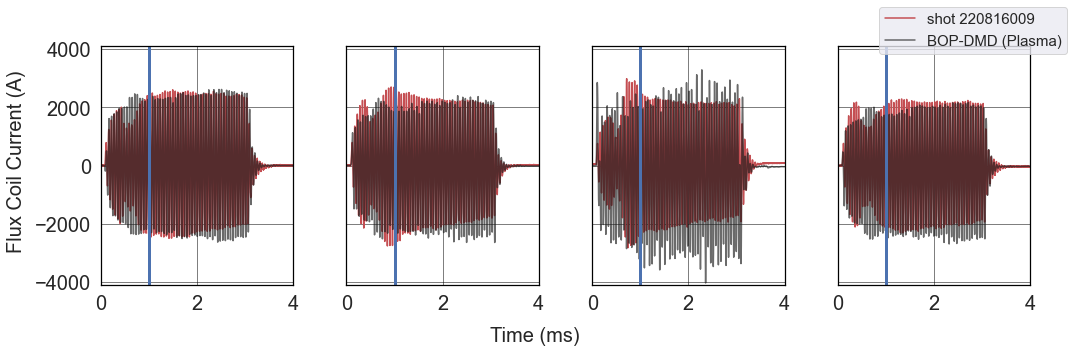

(12, 484)


In [110]:
row = 'L2'
fig ,ax= make_row_graph([flux_trajectory_list[0][251::,:],bop_on_plasma],"",
           ['shot 220816009','BOP-DMD (Plasma)'],False, experiment_time[251::],row, plasma_line=True, ret = True)
    
xout_train = trajectory_list[2][1772::,:]
tout_train = experiment_time[1772::].reshape(len(experiment_time[1772::]))


for k in range(4):
    ax[k].set_ylim([-4100,4100])

plt.savefig(f'BOP-DMD on plasma data {row}.png',bbox_inches="tight")
plt.show()
print(np.shape(xout_train.T))


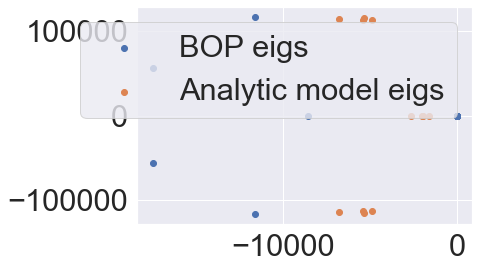

In [111]:
plt.figure()
bop_A_plasma_eigs = np.linalg.eigvals(bop_plasma_A_matrix)
analytic_eigs = np.linalg.eigvals(sysc.A)
plt.scatter(bop_A_plasma_eigs.real,bop_A_plasma_eigs.imag)
plt.scatter(analytic_eigs.real,analytic_eigs.imag)
plt.legend(['BOP eigs','Analytic model eigs'])

In [112]:
print(np.shape(sysc.A))

(12, 12)


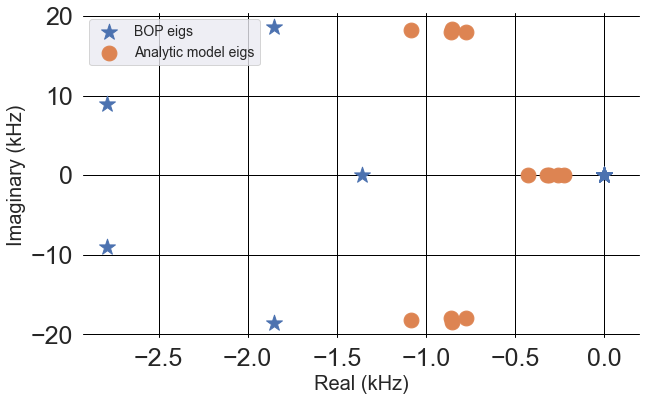

In [113]:
bop_A_plasma_eigs = np.linalg.eigvals(bop_plasma_A_matrix)
analytic_eigs = np.linalg.eigvals(A_plasma)

# Create a figure and axis
fig, ax = plt.subplots(figsize=(10, 6), facecolor='white')

# Scatter plot for eigenvalues
ax.scatter(bop_A_plasma_eigs.real / (2 * 1000 * np.pi), bop_A_plasma_eigs.imag / (1000 * 2 * np.pi), s=280, label='BOP eigs', marker = '*')
ax.scatter(analytic_eigs.real / (2 * 1000 * np.pi), analytic_eigs.imag / (1000 * 2 * np.pi), s=220, label='Analytic model eigs')

# Set labels and legend
ax.set_xlabel('Real (kHz)', fontsize=20)
ax.set_ylabel('Imaginary (kHz)', fontsize=20)
ax.legend(fontsize=14, loc='best')

# Set limits and ticks
ax.set_xlim(right=0.2)
ax.tick_params(labelsize=25)

# Set grid properties
ax.grid(color='black')

# Set background color explicitly
fig.patch.set_facecolor('white')  # Figure background
ax.set_facecolor('white')          # Axes background

# Save the plot
plt.savefig('eigenvalues_of_BOP_plasma_vs_analytic_plasma.png', bbox_inches="tight", facecolor='white', edgecolor='white')
plt.show()

In [114]:
print(bop_A_plasma_eigs)

[-1.16437024e+04-1.16993775e+05j -1.16442587e+04+1.16993027e+05j
 -1.75248549e+04-5.62531183e+04j -1.75242459e+04+5.62531453e+04j
 -8.55445671e+03+1.91188986e-03j -1.11107876e-11+2.69659783e-13j
  4.70659160e-12-9.32064098e-12j  4.07250025e-12+8.51612405e-12j
  6.48463103e-12-5.77988418e-14j -3.15929279e-13-1.18581321e-12j
  6.10116998e-13+1.06074074e-12j -4.10564154e-14-5.72998009e-14j
  6.06234221e-14+2.22778454e-13j]


In [115]:
print(analytic_eigs)

[-6817.1771318 +114445.45628569j -6817.1771318 -114445.45628569j
 -5352.07689318+115776.32829097j -5352.07689318-115776.32829097j
 -5391.09980013+112931.04151052j -5391.09980013-112931.04151052j
 -4880.26154294+112823.37739387j -4880.26154294-112823.37739387j
 -2681.27633926     +0.j         -1423.75686972     +0.j
 -2005.51659351     +0.j         -1950.61292985     +0.j
 -1651.69656928     +0.j        ]


In [116]:
print(np.shape(xout_bop_plasma_new_shot))

(2005, 13)


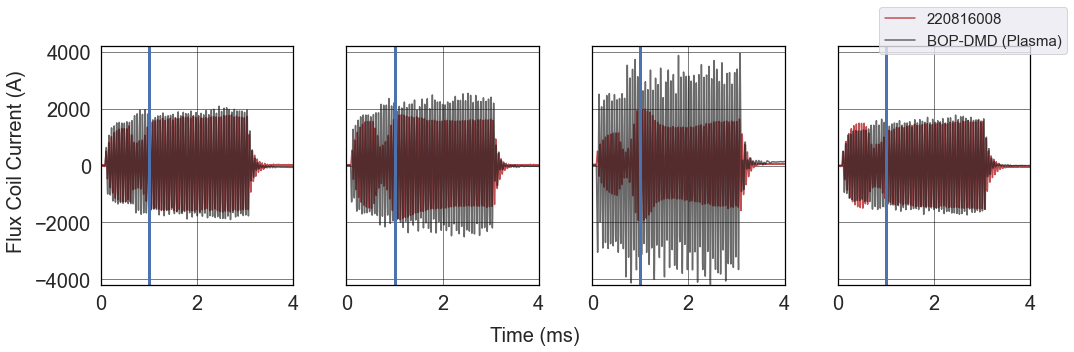

In [117]:

row = 'L2'
fig,ax = make_row_graph([new_plasma_shot_list[0][251::,:],xout_bop_plasma_new_shot],'',['220816008','BOP-DMD (Plasma)'],False,new_plasma_shot_time[251::],row, plasma_line = True, ret = True)

for k in range(4):
    ax[k].set_ylim([-4200,4200])
plt.savefig(f'BOP on new plasma shot {row}',bbox_inches="tight")


## BOP-DMD cannot disambiguate actuation and dynamics, so we train on the last millisecond of a shot when the power supplies have turned off and the circuits are ringing down

In [118]:
rms_opt = mean_squared_error(trajectory_list[2][251::,:].real, xout_opt.real, squared=False)
rms_analytic = mean_squared_error(trajectory_list[2][251::,:].real, xout_sim, squared=False)
print(rms_opt)
print(rms_analytic)

99.02469785659616
138.81261152317333


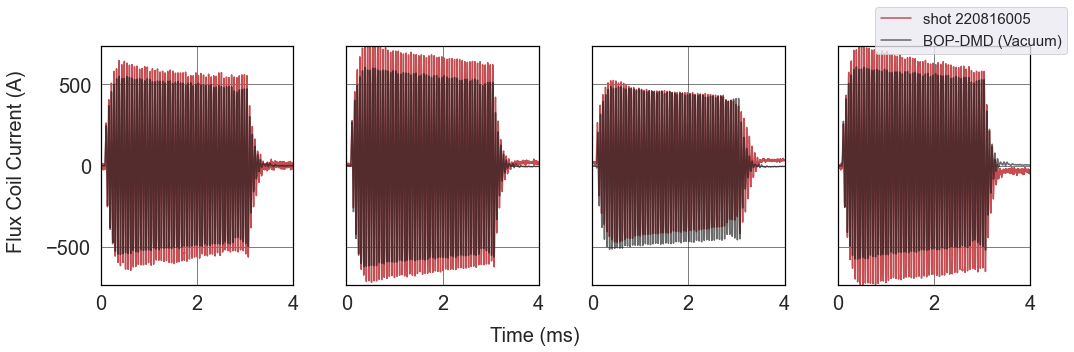

In [119]:
bop_on_vacuum_data = loadmat('data/bop_on_vacuum_data_220816005').get('xout_bop')
row = 'L2'
make_row_graph([trajectory_list[2][251::,:],bop_on_vacuum_data.T],"",
           ['shot 220816005','BOP-DMD (Vacuum)'],False, experiment_time[251::],row)


plt.savefig(f'BOP on vacuum data {row}',bbox_inches="tight")


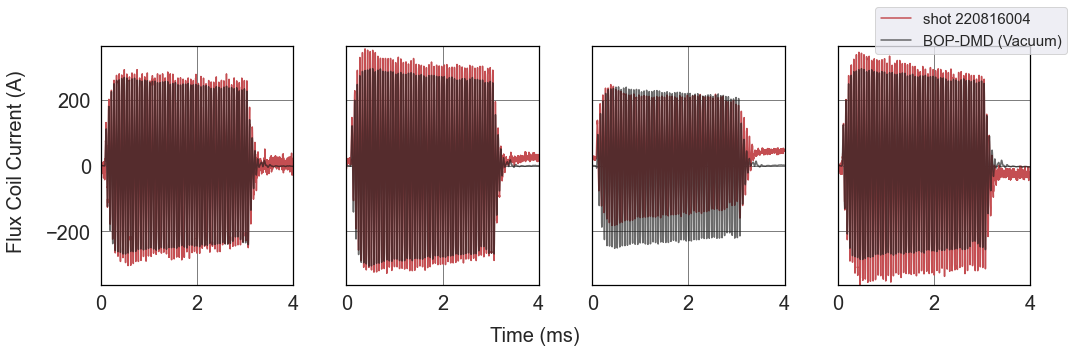

In [120]:
[t,y,xout_bop_220816004] = lsim((bop_A_vacuum,B,C,D),inputs_list[1][251::,:],experiment_time[251::])

make_row_graph([trajectory_list[1][251::,:],xout_bop_220816004],"",
           ['shot 220816004','BOP-DMD (Vacuum)'],False, experiment_time[251::],'L2')


plt.savefig(f'BOP-dmd vs new experimental data {row}',bbox_inches="tight")

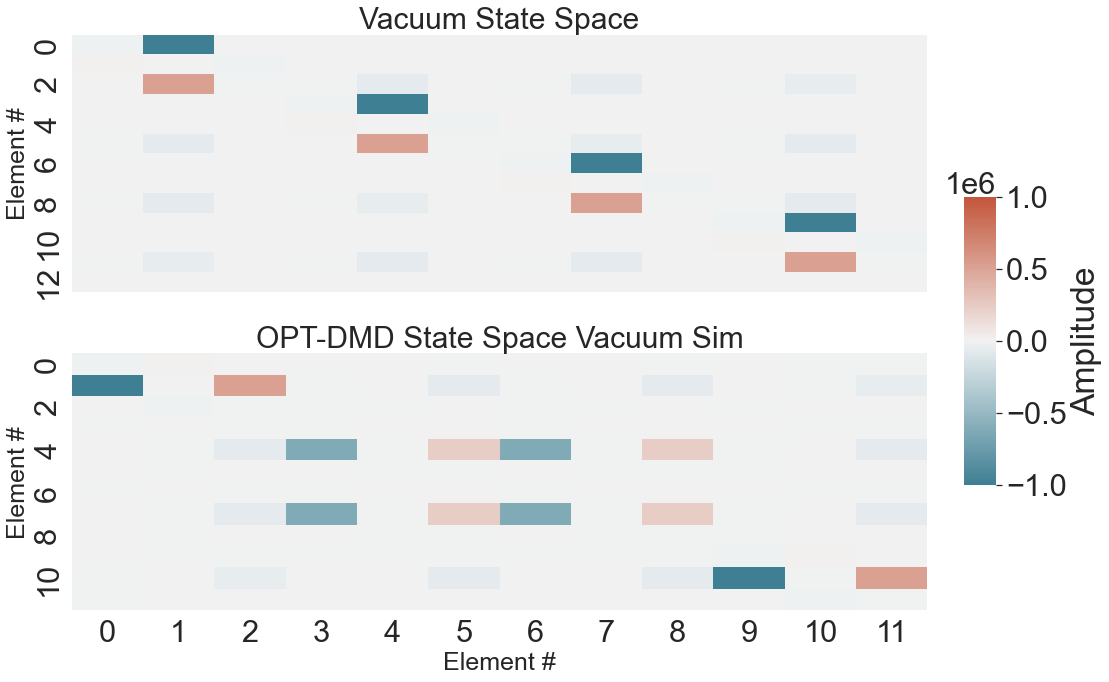

In [121]:

Fontdict = {'fontsize': 30}
A_aug = np.zeros((13, 13))
A_aug[0:12, 0:12] = A
vals = [A_aug, opt_A_sim.real]

# Create figure and axes
fig, axn = plt.subplots(2, 1, figsize=(15, 10), sharex=True)
cbar_ax = fig.add_axes([.91, .3, .03, .4])  # Colorbar axis

# Titles for the subplots
titles = ['Vacuum State Space', 'OPT-DMD State Space Vacuum Sim']

# Create the heatmaps
for i, ax in enumerate(axn.flat):
    sns.heatmap(data=vals[i], ax=ax,
                 cbar=i == 0,
                 cbar_ax=None if i else cbar_ax,
                 vmin=-1e6, vmax=1e6,
                 cmap=sns.diverging_palette(220, 20, as_cmap=True), cbar_kws={'label': 'Amplitude'})  # Diverging color palett
    ax.set_ylabel('Element #', fontsize = 25)
    ax.set_title(titles[i], fontdict=Fontdict) 
ax.set_xlabel('Element #', fontsize = 25)

# Set color palette and style
sns.set(font_scale=2)
fig.tight_layout(rect=[0, 0, .9, 1])

# Save the figure
plt.savefig('OPT-DMD_heatmap_on_simulated_data.png', bbox_inches='tight')
plt.show()

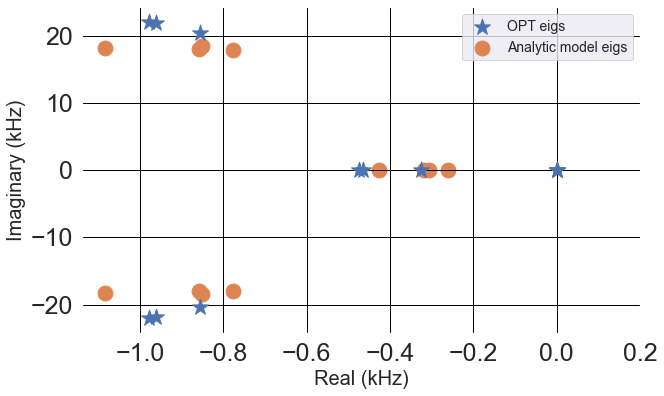

In [122]:
# Plot of the eigenvalues of the opt dmd vs. analytic model
vals = [A_aug, opt_A_sim.real]
opt_A_eigs = np.linalg.eigvals(opt_A_sim)
analytic_eigs = np.linalg.eigvals(A_analytic)

# Create a figure and axis
fig, ax = plt.subplots(figsize=(10, 6), facecolor='white')

# Scatter plot for eigenvalues
ax.scatter(opt_A_eigs.real / (2 * 1000 * np.pi), opt_A_eigs.imag / (1000 * 2 * np.pi), s=280, label='OPT eigs', marker = '*')
ax.scatter(analytic_eigs.real / (2 * 1000 * np.pi), analytic_eigs.imag / (1000 * 2 * np.pi), s=220, label='Analytic model eigs', zorder = 0)

# Set labels and legend
ax.set_xlabel('Real (kHz)', fontsize=20)
ax.set_ylabel('Imaginary (kHz)', fontsize=20)
ax.legend(fontsize=14, loc='best')

# Set limits and ticks
ax.set_xlim(right=0.2)
ax.tick_params(labelsize=25)

# Set grid properties
ax.grid(color='black')

# Set background color explicitly
fig.patch.set_facecolor('white')  # Figure background
ax.set_facecolor('white')          # Axes background

# Save the plot
plt.savefig('eigenvalues_of_OPT_Vacuum_vs_analytic_plasma.png', bbox_inches="tight", facecolor='white', edgecolor='white')
plt.show()

In [123]:
print(np.linalg.matrix_rank(bop_A_vacuum_sim))

12


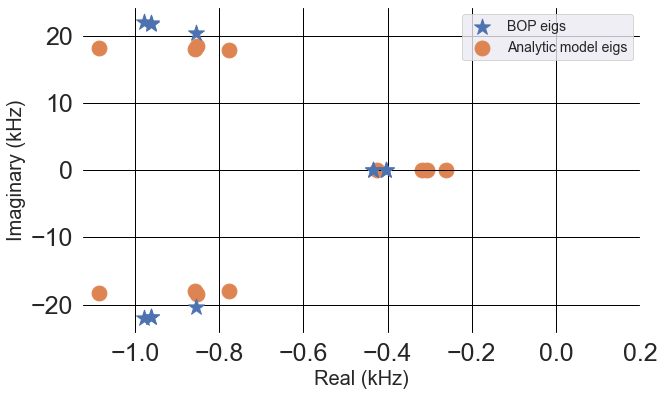

In [124]:
# Plot of the eigenvalues of the opt dmd vs. analytic model

bop_A_eigs = np.linalg.eigvals(bop_A_vacuum_sim)
analytic_eigs = np.linalg.eigvals(A_analytic)

# Create a figure and axis
fig, ax = plt.subplots(figsize=(10, 6), facecolor='white')

# Scatter plot for eigenvalues
ax.scatter(bop_A_eigs.real / (2 * 1000 * np.pi), bop_A_eigs.imag / (1000 * 2 * np.pi), s=280, label='BOP eigs', marker = '*')
ax.scatter(analytic_eigs.real / (2 * 1000 * np.pi), analytic_eigs.imag / (1000 * 2 * np.pi), s=220, label='Analytic model eigs', zorder = 0)

# Set labels and legend
ax.set_xlabel('Real (kHz)', fontsize=20)
ax.set_ylabel('Imaginary (kHz)', fontsize=20)
ax.legend(fontsize=14, loc='best')

# Set limits and ticks
ax.set_xlim(right=0.2)
ax.tick_params(labelsize=25)

# Set grid properties
ax.grid(color='black')

# Set background color explicitly
fig.patch.set_facecolor('white')  # Figure background
ax.set_facecolor('white')          # Axes background

# Save the plot
plt.savefig('eigenvalues_of_BOP_Vacuum_vs_analytic_plasma.png', bbox_inches="tight", facecolor='white', edgecolor='white')
plt.show()

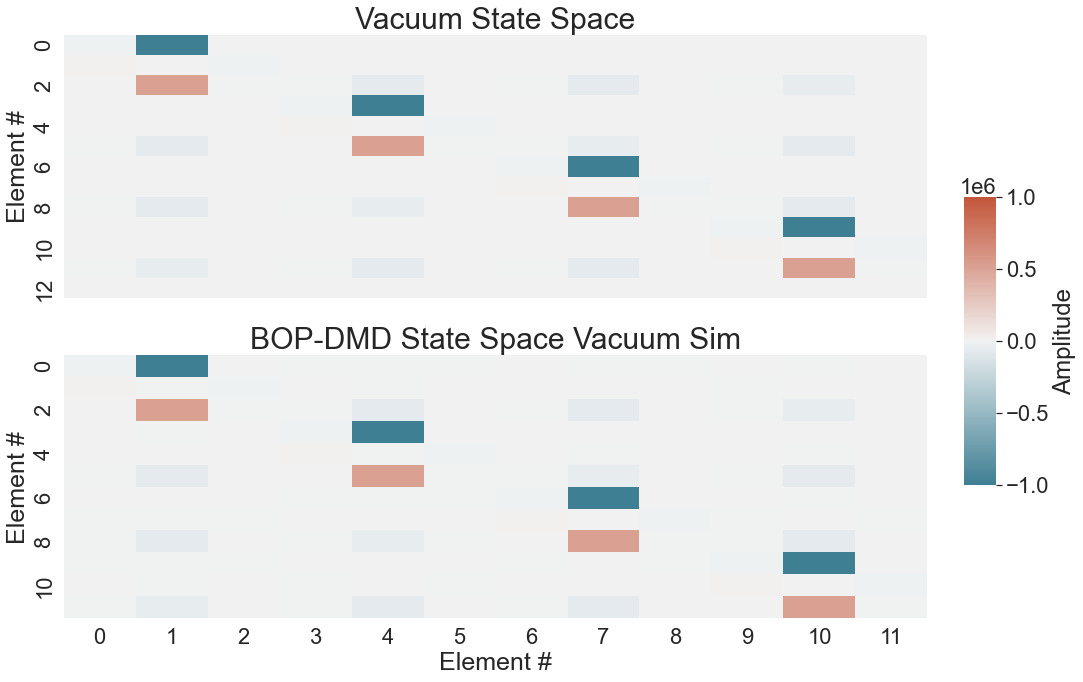

In [125]:

Fontdict = {'fontsize': 30}
A_aug = np.zeros((13, 13))
A_aug[0:12, 0:12] = A
vals = [A_aug, bop_A_vacuum_sim.real]

# Create figure and axes
fig, axn = plt.subplots(2, 1, figsize=(15, 10), sharex=True)
cbar_ax = fig.add_axes([.91, .3, .03, .4])  # Colorbar axis

# Titles for the subplots
titles = ['Vacuum State Space', 'BOP-DMD State Space Vacuum Sim']

# Create the heatmaps
for i, ax in enumerate(axn.flat):
    sns.heatmap(data=vals[i], ax=ax,
                 cbar=i == 0,
                 cbar_ax=None if i else cbar_ax,
                 vmin=-1e6, vmax=1e6,
                 cmap=sns.diverging_palette(220, 20, as_cmap=True), cbar_kws={'label': 'Amplitude'})  # Diverging color palette
    ax.set_ylabel('Element #', fontsize = 25)
    ax.set_title(titles[i], fontdict=Fontdict)
ax.set_xlabel('Element #', fontsize = 25)
# Set color palette and style
sns.set(font_scale=2)
fig.tight_layout(rect=[0, 0, .9, 1])

# Save the figure
plt.savefig('BOP-DMD_heatmap_on_simulated_data.png', bbox_inches='tight')
plt.show()

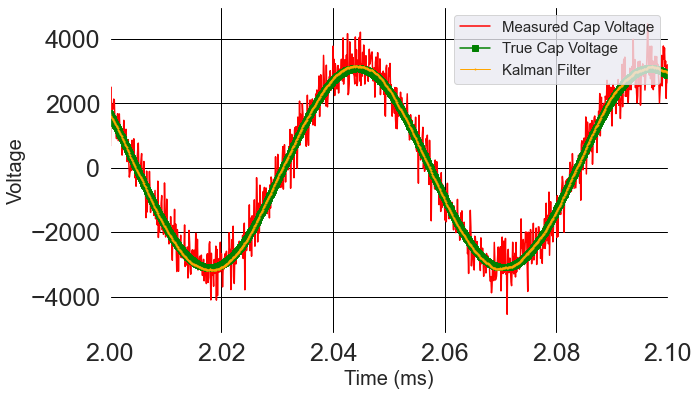

In [126]:
cap_voltage_kf = loadmat('data/plotting_data/Simulink_model_data/Cap_voltage_Kalman_Filter').get('C_Voltage_Approx_Flux_1')
cap_voltage_no_noise = loadmat('data/plotting_data/Simulink_model_data/Cap_voltage_no_noise').get('C_Voltage_No_Noise')
cap_voltage_with_noise = loadmat('data/plotting_data/Simulink_model_data/Cap_voltage_.1_noise_power').get('C_Voltage_Flux_1')

time = np.linspace(0, 0.004, len(cap_voltage_kf))
time = [t*1000 for t in time]


# Create a figure and axis
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('white')  # Set figure background color to white
ax.set_facecolor('white')          # Set axis background color to white

# Plot the data
ax.plot(time, cap_voltage_with_noise, label='Measured Cap Voltage', color='red', linewidth=1.5)
ax.plot(time, cap_voltage_no_noise, label='True Cap Voltage', color='green', marker='s', markersize=6)
ax.plot(time, cap_voltage_kf, label='Kalman Filter', color='orange', marker='o', markersize=1, linewidth=1)

# Add legend, labels, and customize font sizes
ax.legend(fontsize=15, loc='upper right')
ax.set_title('', fontsize='large')
ax.set_xlabel('Time (ms)', fontsize=20)
ax.set_ylabel('Voltage', fontsize=20)
ax.tick_params(axis='x', labelsize=25)
ax.tick_params(axis='y', labelsize=25)

# Set x-axis limits
ax.set_xlim(2, 2.1)

# Add a black grid
ax.grid(color='black')

# Save the plot with a white background
plt.savefig('Kalman_Filter_on_noisy_Cap_data.png', bbox_inches="tight", facecolor='white', edgecolor='white')
plt.show()

(13, 13)


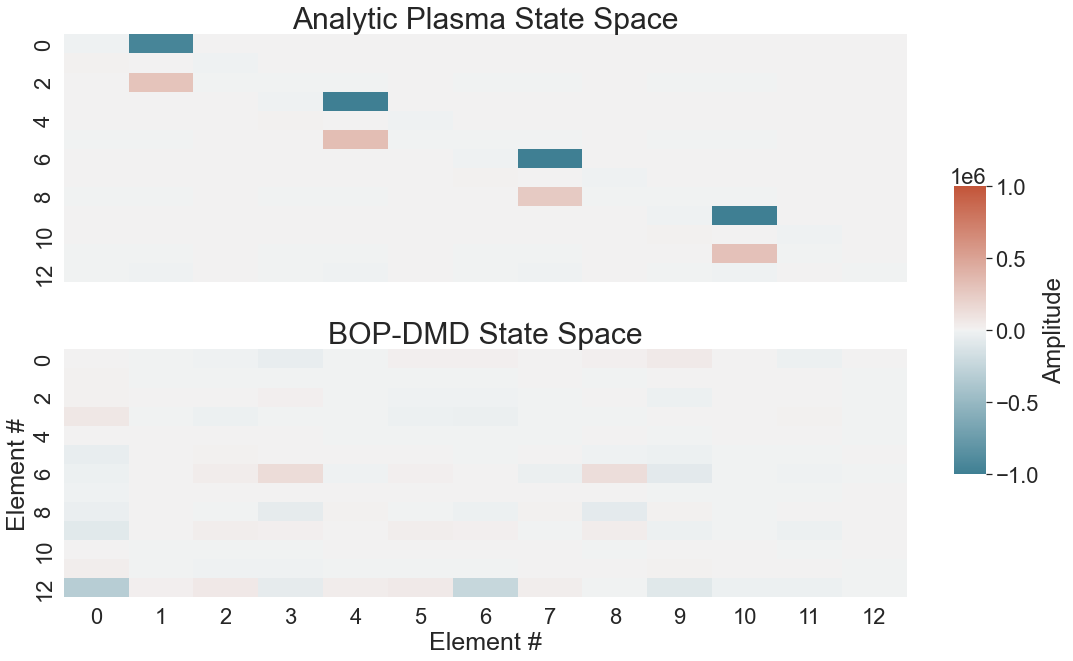

In [127]:
df = pd.DataFrame(np.random.random((10,10,)))

Fontdict = {'fontsize': 30}
print(np.shape(A_aug))
vals = [A_plasma,bop_plasma_A_matrix.real]
fig, axn = plt.subplots(2, 1,figsize = (15,10),sharex = True)
cbar_ax = fig.add_axes([.91, .3, .03, .4])
# (figsize = (20,15))
titles = ['Analytic Plasma State Space','BOP-DMD State Space']
for i, ax in enumerate(axn.flat):
    sns.heatmap(data = vals[i], ax=ax,
                cbar=i == 0,
                cbar_ax=None if i else cbar_ax,vmin = -1e6, vmax = 1e6,
                cmap=sns.diverging_palette(220, 20, as_cmap=True), cbar_kws={'label': 'Amplitude'})
    
    # Sets title color
    
    ax.set_title(titles[i],fontdict = Fontdict)
    sns.color_palette("Dark2", as_cmap=True)
    sns.set(font_scale=2.8)
ax.set_ylabel('Element #', fontsize = 25)
ax.set_title(titles[i], fontdict=Fontdict)
ax.set_xlabel('Element #', fontsize = 25)
fig.tight_layout(rect=[0, 0, .9, 1])
plt.savefig('BOP-DMD and Analytic Plasma Model heatmap',bbox_inches = 'tight')




# Analysis for Matrix norms

In [128]:
norm_comparison = np.linalg.norm(A_plasma - bop_plasma_A_matrix.real)/np.linalg.norm(A_plasma)

In [129]:
norm_comparison

1.0154395675420038

# UQ and Different BOP Trajectories

In [130]:
A_matrices_BOP_DMD = loadmat('data/Plasma_A_matrices_BOP_DMD.mat').get('atilde_cell_list') #load in all A matrices from a 20 trial run of BOP-DMD

In [131]:
print(len(A_matrices_BOP_DMD.T))

20


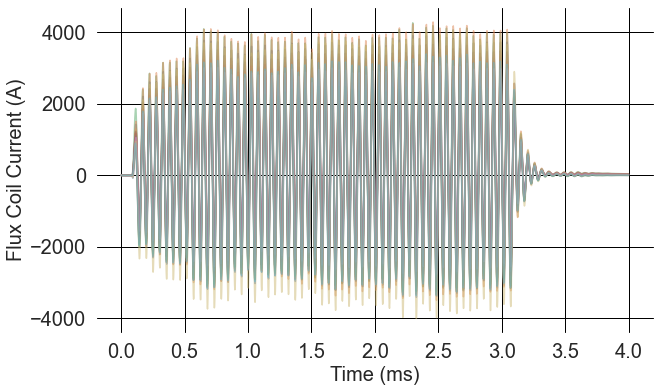

In [132]:
bop_trajectory_list = []

# Create a figure and axis
fig, ax = plt.subplots(figsize=(10, 6), facecolor='w')

# Set labels and ticks
ax.set_xlabel('Time (ms)', fontsize=20)
ax.set_ylabel('Flux Coil Current (A)', fontsize=20)
ax.tick_params(axis='x', labelsize=20)
ax.tick_params(axis='y', labelsize=20)
ax.grid(color='black')
# Plotting the trajectories
for k in range(len(A_matrices_BOP_DMD.T)):
    A_mat = A_matrices_BOP_DMD[0, k]
    xout = lsim((A_mat, B_13, C_13, D), flux_inputs_list[0][251::, :], experiment_time[251::])[2]
    bop_trajectory_list.append(xout)
    ax.plot(1000 * experiment_time[251::], xout[:, 2].real, alpha=0.5)
ax.set_facecolor('w')
# Save the plot
plt.savefig('individual_bop_trajectories_L2_flux_1.png', bbox_inches='tight')
plt.show()

In [133]:
print(np.shape(train))

U  = scipy.linalg.svd(train,full_matrices= False)[0]

(13, 484)


In [134]:
print(np.shape(U))

(13, 13)


In [135]:
print(np.shape(bop_plasma_A_matrix.real))
U_r = U[:,0:9]
print(np.shape(U_r))

(13, 13)
(13, 9)


In [136]:
print(np.shape(U_r.T.conj()))

(9, 13)


In [137]:
reduced_bop_plasma_A_matrix = U_r.T.conj()@bop_plasma_A_matrix.real@U_r